<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/CH_3/DIMENSION_Rejection_vs_RWM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import sys

repo_name = 'MCMC-MonteCarlo-TFG'
repo_url = f'https://github.com/mateoveega/{repo_name}.git'

if not os.path.exists(f'/content/{repo_name}'):
    !git clone {repo_url}

if f'/content/{repo_name}' not in sys.path:
    sys.path.append(f'/content/{repo_name}')

from samplers import box_muller
from samplers import rejection
from scipy.stats import multivariate_normal

import numpy as np
import matplotlib.pyplot as plt

Cloning into 'MCMC-MonteCarlo-TFG'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (95/95), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 95 (delta 30), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (95/95), 2.97 MiB | 13.21 MiB/s, done.
Resolving deltas: 100% (30/30), done.


In [2]:
# Parámetros para observar cómo la dimensión afecta a la tasa de aceptación
dimensions = [2, 5, 10, 20, 50]
sigma_q = 2.0
num_samples = 10000

acceptance_rates = [] # Para graficar los resultados más adelante

for d in dimensions:
    # La constante óptima k crece exponencialmente con la dimensión
    k = sigma_q ** d

    # Definimos la PDF objetivo (Normal estándar) y la propuesta (ensanchada por sigma_q)
    target_pdf = multivariate_normal(mean=np.zeros(d), cov=np.eye(d)).pdf
    proposal_pdf = multivariate_normal(mean=np.zeros(d), cov=(sigma_q**2) * np.eye(d)).pdf

    # Adaptador para fijar la dimensión 'd' y dejar solo el argumento 'n' libre
    proposal_sampler = lambda n: box_muller(D=d, num_samples=n)

    accepted_samples, accepted_rate = rejection(target_pdf, proposal_pdf, proposal_sampler, k, num_samples)

    acceptance_rates.append(accepted_rate)

    print(f"Dimensión: {d}, Tasa de aceptación: {accepted_rate:.4f}")

Dimensión: 2, Tasa de aceptación: 0.5682
Dimensión: 5, Tasa de aceptación: 0.2413
Dimensión: 10, Tasa de aceptación: 0.0606
Dimensión: 20, Tasa de aceptación: 0.0000
Dimensión: 50, Tasa de aceptación: 0.0000


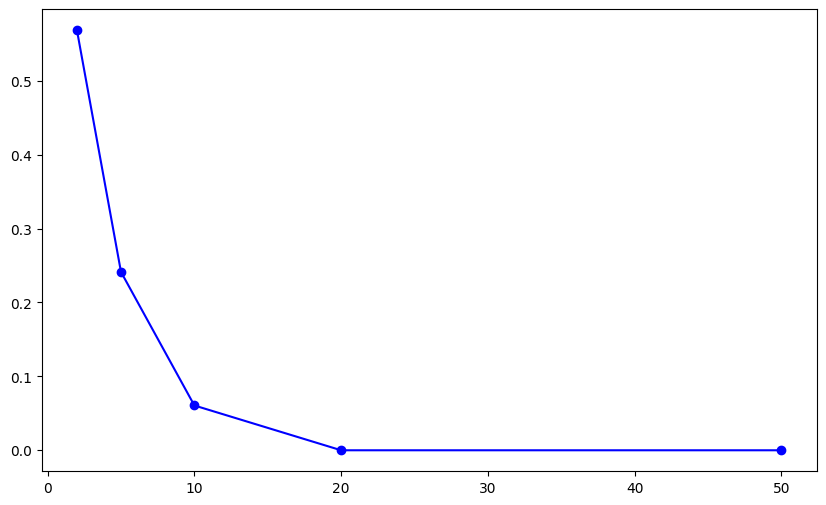

La gráfica enfrenta la tasa de aceptación del muestreo por rechazo, frente a la dimensión.


In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(dimensions, acceptance_rates, marker='o', linestyle='-', color='b')

plt.savefig('DIMENSION_RECHAZO.pdf')

plt.show()

print("La gráfica enfrenta la tasa de aceptación del muestreo por rechazo, frente a la dimensión.")

In [4]:
from google.colab import files
files.download("DIMENSION_RECHAZO.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal

def random_walk_metropolis(d, num_iterations, initial_position, sigma_proposal):
    accepted_samples = []
    accepted_count = 0

    # Define la distribución objetivo (Normal estándar, d - dimensional)
    target_pdf = multivariate_normal(mean=np.zeros(d), cov=np.eye(d)).pdf

    # Fijamos la posición inicial
    current_position = np.array(initial_position)

    # Repetimos el algoritmo num_iterations veces
    for i in range(num_iterations):
        # Genera una propuesta de nuevo estado z_prime
        # La distribución propuesta es una Normal multivariada centrada en 0 con covarianza sigma_proposal^2 * I
        proposal_noise = multivariate_normal(mean=np.zeros(d), cov=(sigma_proposal**2) * np.eye(d)).rvs()
        z_prime = current_position + proposal_noise

        # Calcula la probabilidad de aceptación alpha
        # Manejar el caso donde target_pdf(current_position) sea muy cercano a cero
        p_current = target_pdf(current_position)
        p_prime = target_pdf(z_prime)

        if p_current == 0 and p_prime > 0:
            alpha = 1
        elif p_current == 0 and p_prime == 0:
            alpha = 0 # Or handle as a specific case, here assuming 0
        elif p_current > 0:
            alpha = min(1, p_prime / p_current)
        else: # p_current < 0 is not possible for PDF
            alpha = 0

        # Genera un número aleatorio uniforme u
        u = np.random.rand()

        # Si u <= alpha, actualiza current_position y el contador de aceptaciones
        if u <= alpha:
            current_position = z_prime
            accepted_count += 1

        # Agrega la current_position a la lista de muestras aceptadas
        accepted_samples.append(current_position.copy())

    # Calcula la tasa de aceptación
    acceptance_rate = accepted_count / num_iterations

    # La función devuelve la lista de muestras aceptadas y la tasa de aceptación
    return np.array(accepted_samples), acceptance_rate

In [ ]:
d = 50

np.random.seed(3) # Garantizar reproducibilidad del experimento

num_iterations = 5000
initial_position = np.zeros(d)
sigma_proposal = 0.1

rwm_samples, rwm_acceptance_rate = random_walk_metropolis(d, num_iterations, initial_position, sigma_proposal)

print(f"Tasa de aceptación por RWM: {rwm_acceptance_rate:.4f}")


Tasa de aceptación por RWM: 0.7226
